# 00 — Optimizasyona Giriş ve Temeller

**Yapay Zeka Mühendisliği · Optimizasyon Algoritmaları Dersi**

---

## Bu notebook'ta ne var?

| Bölüm | Konu |
|---|---|
| 1 | Makine öğrenmesi neden bir optimizasyon problemidir? |
| 2 | Gradyan, yönlü türev ve en dik iniş yönünün türetimi |
| 3 | Öğrenme oranı ve kararlılık sınırı $\eta < 2/L$ |
| 4 | Koşul sayısı: zikzak probleminin kaynağı |
| 5 | Konveks olmayan dünya: yerel minimum, eyer noktası, plato |
| 6 | Batch / Mini-batch / Stokastik gradyan |
| 7 | Gradyan doğrulama (her "from scratch" işin olmazsa olmazı) |
| 8 | Derste kullanacağımız ortak arayüz |
| 9 | Alıştırmalar |

## Ön koşullar
Çok değişkenli türev, temel lineer cebir (özdeğer kavramı), NumPy.

## Ders felsefesi: *from scratch*
Her algoritmayı **önce kâğıt üstünde türetiyor**, sonra **NumPy ile
sıfırdan yazıyor**, en sonunda referans implementasyonla
karşılaştırıyoruz. Hiçbir yerde otomatik türev (autograd) kullanmıyoruz —
tüm gradyanlar elle hesaplanmıştır. Amaç, optimizer'ı kara kutu olmaktan
çıkarmaktır.

In [1]:
# ===========================================================================
# KURULUM — bu notebook kendi kendine yeter
# ---------------------------------------------------------------------------
# Bu hücre, ders boyunca kullanılan `optim` paketinin kaynağını çalışma
# dizinine yazar ve içe aktarır. Kurulum gerektirmez; Colab'de de çalışır.
# Bir kez çalıştırıp geçin — asıl ders bir sonraki hücreden başlıyor.
#
# Paketin tamamı NumPy ile sıfırdan yazılmıştır: otomatik türev (autograd)
# kullanılmaz, tüm gradyanlar elle hesaplanmıştır.
# ===========================================================================
%matplotlib inline

OPTIM_PAKETI = {
"__init__.py": r'''
"""
optim - Yapay Zeka Mühendisliği için sıfırdan optimizasyon algoritmaları.

Bu paket ders boyunca adım adım inşa edilen referans implementasyonları içerir.
Notebook'larda önce algoritmayı kendiniz yazarsınız, sonra buradaki sürümle
karşılaştırırsınız.

Hızlı başlangıç
---------------
>>> import numpy as np
>>> from optim import AdamW, Rosenbrock, optimize_2d
>>> path, losses = optimize_2d(AdamW, Rosenbrock(), [-1.2, 1.0],
...                            n_steps=500, lr=0.05)
>>> float(losses[-1]) < float(losses[0])
True
"""

from .base import Optimizer, optimize_2d, iterate_minibatches, train
from .sgd import SGD, VanillaGD
from .rmsprop import RMSProp, AdaGrad
from .adam import Adam
from .adamw import AdamW, AdamWGrouped
from .lbfgs import LBFGS, lbfgs_minimize, two_loop_recursion, strong_wolfe
from .functions import (
    TestFunction, Quadratic, Rosenbrock, Beale, Saddle, Rastrigin,
    numerical_grad, check_grad, ALL_FUNCTIONS,
)
from .models import LinearRegression, LogisticRegression, MLP, sigmoid, softmax
from . import data, viz

__version__ = "1.0.0"

__all__ = [
    "Optimizer", "optimize_2d", "iterate_minibatches", "train",
    "SGD", "VanillaGD", "RMSProp", "AdaGrad", "Adam", "AdamW", "AdamWGrouped",
    "LBFGS", "lbfgs_minimize", "two_loop_recursion", "strong_wolfe",
    "TestFunction", "Quadratic", "Rosenbrock", "Beale", "Saddle", "Rastrigin",
    "numerical_grad", "check_grad", "ALL_FUNCTIONS",
    "LinearRegression", "LogisticRegression", "MLP", "sigmoid", "softmax",
    "data", "viz", "__version__",
]
''',

"base.py": r'''
"""
Temel optimizer arayüzü ve ortak yardımcı fonksiyonlar.

Bu derste optimizer'lar PyTorch'un tasarım desenini taklit eder:

    optimizer = SGD(params, lr=0.1, momentum=0.9)
    for epoch in range(n_epochs):
        grads = model.backward(...)      # gradyanları hesapla
        optimizer.step(grads)            # parametreleri güncelle

`params` bir NumPy dizisi listesidir ve **yerinde (in-place)** güncellenir.
Bu sayede model nesnesi ile optimizer aynı bellek bölgesini paylaşır,
tıpkı PyTorch'ta olduğu gibi.
"""

from __future__ import annotations

import numpy as np


class Optimizer:
    """Tüm optimizer'ların türetildiği taban sınıf.

    Parameters
    ----------
    params : list[np.ndarray]
        Optimize edilecek parametre dizileri. Yerinde güncellenirler.
    lr : float
        Öğrenme oranı (learning rate).
    """

    def __init__(self, params, lr):
        self.params = list(params)
        if lr <= 0:
            raise ValueError(f"Öğrenme oranı pozitif olmalı, verilen: {lr}")
        self.lr = float(lr)
        self.t = 0  # adım sayacı (bias düzeltmesi için kritik)
        self.state = [self._init_state(p) for p in self.params]

    # ---- alt sınıfların dolduracağı kısımlar -------------------------------
    def _init_state(self, p):
        """Parametre başına tutulacak durum (momentum, ikinci moment, ...)."""
        return {}

    def step(self, grads):
        """Bir optimizasyon adımı at. `grads`, `params` ile aynı sıradadır."""
        raise NotImplementedError

    # ---- ortak yardımcılar -------------------------------------------------
    def _check(self, grads):
        if len(grads) != len(self.params):
            raise ValueError(
                f"{len(self.params)} parametre bekleniyordu, {len(grads)} gradyan geldi."
            )
        return [np.asarray(g, dtype=float) for g in grads]

    def state_memory_bytes(self):
        """Optimizer durumunun bellek maliyeti (bayt).

        Adam'ın neden SGD'nin iki katı bellek yediğini somut görmek için."""
        total = 0
        for st in self.state:
            for v in st.values():
                if isinstance(v, np.ndarray):
                    total += v.nbytes
        return total

    def param_memory_bytes(self):
        return sum(p.nbytes for p in self.params)

    def __repr__(self):
        return f"{self.__class__.__name__}(lr={self.lr})"


# ---------------------------------------------------------------------------
# 2B test fonksiyonları üzerinde optimizer koşturma
# ---------------------------------------------------------------------------
def optimize_2d(optimizer_cls, fn, x0, n_steps=100, **opt_kwargs):
    """2 boyutlu bir test fonksiyonu üzerinde optimizer'ı koştur.

    Parameters
    ----------
    optimizer_cls : type
        Optimizer sınıfı (SGD, Adam, ...).
    fn : TestFunction
        `value(x)` ve `grad(x)` metotlarına sahip fonksiyon nesnesi.
    x0 : array-like, shape (2,)
        Başlangıç noktası.
    n_steps : int
        Atılacak adım sayısı.

    Returns
    -------
    path : np.ndarray, shape (n_steps+1, 2)
        Ziyaret edilen noktalar.
    losses : np.ndarray, shape (n_steps+1,)
        Her noktadaki fonksiyon değeri.
    """
    x = np.array(x0, dtype=float)
    opt = optimizer_cls([x], **opt_kwargs)

    path = [x.copy()]
    losses = [fn.value(x)]

    for _ in range(n_steps):
        g = fn.grad(x)
        if not np.all(np.isfinite(g)):
            break
        opt.step([g])
        if not np.all(np.isfinite(x)):
            break
        path.append(x.copy())
        losses.append(fn.value(x))

    return np.array(path), np.array(losses)


# ---------------------------------------------------------------------------
# Mini-batch üreteci
# ---------------------------------------------------------------------------
def iterate_minibatches(X, y, batch_size, shuffle=True, rng=None):
    """Veriyi mini-batch'lere böler. SGD'nin 'S' harfi buradan gelir."""
    n = X.shape[0]
    idx = np.arange(n)
    if shuffle:
        rng = np.random.default_rng() if rng is None else rng
        rng.shuffle(idx)
    for start in range(0, n, batch_size):
        sel = idx[start:start + batch_size]
        yield X[sel], y[sel]


def train(model, X, y, optimizer, n_epochs=20, batch_size=32,
          X_val=None, y_val=None, seed=0, verbose=False):
    """Genel eğitim döngüsü: her optimizer ile aynı kodu kullanacağız.

    Returns
    -------
    history : dict
        'epoch_loss', 'batch_loss', 'val_loss', 'val_acc' anahtarlarını içerir.
    """
    rng = np.random.default_rng(seed)
    history = {"epoch_loss": [], "batch_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(n_epochs):
        epoch_losses = []
        for xb, yb in iterate_minibatches(X, y, batch_size, rng=rng):
            loss, grads = model.loss_and_grads(xb, yb)
            optimizer.step(grads)
            epoch_losses.append(loss)
            history["batch_loss"].append(loss)

        history["epoch_loss"].append(float(np.mean(epoch_losses)))

        if X_val is not None:
            val_loss, _ = model.loss_and_grads(X_val, y_val)
            history["val_loss"].append(float(val_loss))
            if hasattr(model, "accuracy"):
                history["val_acc"].append(float(model.accuracy(X_val, y_val)))

        if verbose and (epoch % max(1, n_epochs // 10) == 0):
            msg = f"epoch {epoch:3d} | train {history['epoch_loss'][-1]:.4f}"
            if X_val is not None:
                msg += f" | val {history['val_loss'][-1]:.4f}"
            print(msg)

    return history
''',

"sgd.py": r'''
"""
SGD, Momentum ve Nesterov İvmeli Gradyan (NAG).

Matematiksel formülasyon (PyTorch konvansiyonu ile birebir uyumlu):

    g_t = ∇L(w_t) + λ·w_t                     (λ = weight_decay, L2)

    momentum = 0 ise:
        w_{t+1} = w_t - η·g_t

    momentum = μ > 0 ise:
        b_t     = μ·b_{t-1} + g_t              (b_0 = g_0)
        d_t     = g_t + μ·b_t   (Nesterov)     ya da   d_t = b_t (klasik)
        w_{t+1} = w_t - η·d_t

DİKKAT: Literatürdeki klasik momentum formülü genellikle
    v_t = μ·v_{t-1} - η·g_t ;  w_{t+1} = w_t + v_t
şeklinde yazılır. İkisi η sabitken eşdeğerdir; fark, η değiştiğinde
birikmiş momentumun yeniden ölçeklenip ölçeklenmediğidir.
PyTorch ikinci (yukarıdaki) formu kullandığı için biz de onu kullanıyoruz.
"""

from __future__ import annotations

import numpy as np

from .base import Optimizer


class SGD(Optimizer):
    """Stokastik Gradyan İnişi (+ momentum, + Nesterov, + weight decay).

    Parameters
    ----------
    lr : float
        Öğrenme oranı. SGD için tipik değerler Adam'dan ~100-1000 kat büyüktür
        (ör. ResNet + batch 256 için 0.1).
    momentum : float, default 0.0
        μ katsayısı. 0.9 pratikte neredeyse her zaman iyi bir başlangıçtır.
    nesterov : bool, default False
        True ise momentum yönünde "ileri bakarak" gradyan uygular.
    weight_decay : float, default 0.0
        L2 düzenlileştirme katsayısı; gradyana λ·w ekler.
    """

    def __init__(self, params, lr=0.01, momentum=0.0, nesterov=False,
                 weight_decay=0.0):
        if nesterov and momentum <= 0:
            raise ValueError("Nesterov için momentum > 0 olmalı.")
        self.momentum = float(momentum)
        self.nesterov = bool(nesterov)
        self.weight_decay = float(weight_decay)
        super().__init__(params, lr)

    def _init_state(self, p):
        # Momentum kullanılmıyorsa hiç bellek ayırmıyoruz: SGD'nin ucuzluğu burada.
        if self.momentum > 0:
            return {"buf": np.zeros_like(p)}
        return {}

    def step(self, grads):
        grads = self._check(grads)
        self.t += 1

        for p, g, st in zip(self.params, grads, self.state):
            if self.weight_decay != 0.0:
                g = g + self.weight_decay * p          # L2 (coupled) decay

            if self.momentum > 0:
                buf = st["buf"]
                if self.t == 1:
                    # İlk adımda tampon doğrudan gradyana eşitlenir (PyTorch davranışı)
                    buf[...] = g
                else:
                    buf[...] = self.momentum * buf + g

                d = g + self.momentum * buf if self.nesterov else buf
            else:
                d = g

            p -= self.lr * d                            # yerinde güncelleme


class VanillaGD(SGD):
    """Momentumsuz saf gradyan inişi - okunabilirlik için ince bir sarmalayıcı."""

    def __init__(self, params, lr=0.01, weight_decay=0.0):
        super().__init__(params, lr=lr, momentum=0.0, weight_decay=weight_decay)
''',

"rmsprop.py": r'''
"""
AdaGrad ve RMSProp: parametre başına uyarlanabilir öğrenme oranı.

AdaGrad (Duchi ve ark., 2011):
    G_t = G_{t-1} + g_t²                     (karesel gradyan BİRİKİMİ)
    w_{t+1} = w_t - η·g_t / (√G_t + ε)

    Sorun: G_t monoton artar ⇒ efektif öğrenme oranı sıfıra iner ve
    eğitim fiilen durur. Seyrek (sparse) özelliklerde ise tam da bu
    davranış işe yarar: nadir görülen özellikler büyük adım alır.

RMSProp (Hinton, 2012 - ders notu, makale yok):
    v_t = α·v_{t-1} + (1-α)·g_t²             (BİRİKİM yerine HAREKETLİ ORTALAMA)
    w_{t+1} = w_t - η·g_t / (√v_t + ε)

    Üstel ortalama sayesinde v_t sınırlı kalır, öğrenme oranı sönmez.
    Durağan olmayan (non-stationary) hedeflerde - RNN, pekiştirmeli
    öğrenme - bu yüzden tercih edilir.

ε'un YERİ önemlidir. Biz PyTorch konvansiyonunu kullanıyoruz:
    g / (√v + ε)     değil    g / √(v + ε)
İkisi arasındaki fark RL gibi hassas alanlarda sonucu değiştirebilir.
"""

from __future__ import annotations

import numpy as np

from .base import Optimizer


class AdaGrad(Optimizer):
    """Adaptif Gradyan. Karesel gradyanları biriktirir."""

    def __init__(self, params, lr=0.01, eps=1e-10, weight_decay=0.0):
        self.eps = float(eps)
        self.weight_decay = float(weight_decay)
        super().__init__(params, lr)

    def _init_state(self, p):
        return {"G": np.zeros_like(p)}

    def step(self, grads):
        grads = self._check(grads)
        self.t += 1
        for p, g, st in zip(self.params, grads, self.state):
            if self.weight_decay != 0.0:
                g = g + self.weight_decay * p
            st["G"] += g * g
            p -= self.lr * g / (np.sqrt(st["G"]) + self.eps)


class RMSProp(Optimizer):
    """RMSProp: karesel gradyanın üstel hareketli ortalaması.

    Parameters
    ----------
    lr : float, default 1e-3
    alpha : float, default 0.99
        Düzleştirme katsayısı (PyTorch'ta `alpha`, TF'de `rho`).
        0.9 daha hızlı tepki verir, 0.99 daha pürüzsüzdür.
    eps : float, default 1e-8
        Sıfıra bölmeyi engeller; paydada karekökün DIŞINDA durur.
    momentum : float, default 0.0
        > 0 ise normalize edilmiş gradyan üzerine klasik momentum eklenir.
    centered : bool, default False
        True ise gradyanın ortalaması da izlenir ve varyans
        v - m² ile kestirilir. Daha kararlı ama bir kat daha pahalı.
    """

    def __init__(self, params, lr=1e-3, alpha=0.99, eps=1e-8,
                 weight_decay=0.0, momentum=0.0, centered=False):
        self.alpha = float(alpha)
        self.eps = float(eps)
        self.weight_decay = float(weight_decay)
        self.momentum = float(momentum)
        self.centered = bool(centered)
        super().__init__(params, lr)

    def _init_state(self, p):
        st = {"v": np.zeros_like(p)}
        if self.momentum > 0:
            st["buf"] = np.zeros_like(p)
        if self.centered:
            st["g_avg"] = np.zeros_like(p)
        return st

    def step(self, grads):
        grads = self._check(grads)
        self.t += 1

        for p, g, st in zip(self.params, grads, self.state):
            if self.weight_decay != 0.0:
                g = g + self.weight_decay * p

            v = st["v"]
            v[...] = self.alpha * v + (1.0 - self.alpha) * (g * g)

            if self.centered:
                ga = st["g_avg"]
                ga[...] = self.alpha * ga + (1.0 - self.alpha) * g
                denom = np.sqrt(np.maximum(v - ga * ga, 0.0)) + self.eps
            else:
                denom = np.sqrt(v) + self.eps

            upd = g / denom

            if self.momentum > 0:
                buf = st["buf"]
                buf[...] = self.momentum * buf + upd
                upd = buf

            p -= self.lr * upd
''',

"adam.py": r'''
"""
Adam: Adaptive Moment Estimation (Kingma & Ba, 2015).

Fikir tek cümlede: *Momentum* (1. moment) ile *RMSProp* (2. moment)
aynı anda tutulur ve ikisi birleştirilir.

    m_t = β₁·m_{t-1} + (1-β₁)·g_t                  # yön    (momentum)
    v_t = β₂·v_{t-1} + (1-β₂)·g_t²                 # ölçek  (RMSProp)

    m̂_t = m_t / (1 - β₁ᵗ)                          # bias düzeltmesi
    v̂_t = v_t / (1 - β₂ᵗ)

    w_{t+1} = w_t - η · m̂_t / (√v̂_t + ε)

BIAS DÜZELTMESİ NEDEN GEREKLİ?
m_0 = v_0 = 0 ile başladığımız için ilk adımlarda her iki moment de gerçek
değerlerinin ALTINDA kalır: E[m_t] = (1-β₁ᵗ)·E[g], E[v_t] = (1-β₂ᵗ)·E[g²].
Kritik nokta, ikisinin AYNI oranda yanlı olmamasıdır. Düzeltmesiz oran:

    m_t / √v_t  =  (1-β₁ᵗ) / √(1-β₂ᵗ)  ×  (doğru oran)

t=1'de bu çarpan (1-0.9)/√(1-0.999) = 0.1/0.0316 ≈ 3.16'dır. Yani düzeltme
yapılmazsa ilk adım olması gerekenden ~3 kat BÜYÜK atılır ve çarpan yavaşça
1'e iner. Bu erken dönem aşırı adımları eğitimi kararsızlaştırabilir.
(1-β₁ᵗ) ve (1-β₂ᵗ) ile bölmek yanlılığı tam olarak giderir ve ilk adımdan
itibaren adım boyunu η mertebesinde tutar.

ADIM BOYUTU SEZGİSİ:
m̂/√v̂ oranı kabaca "işaretli sinyal/gürültü" ölçüsüdür ve büyüklüğü
1 mertebesindedir. Dolayısıyla Adam'ın attığı adım ≈ η kadardır ve
gradyanın mutlak ölçeğinden bağımsızdır. Adam'ın "kutudan çıktığı gibi
çalışmasının" asıl sebebi budur.
"""

from __future__ import annotations

import numpy as np

from .base import Optimizer


class Adam(Optimizer):
    """Adam optimizer (isteğe bağlı AMSGrad ile).

    Parameters
    ----------
    lr : float, default 1e-3
        Makalenin önerdiği varsayılan. Transformer ön-eğitiminde 1e-4..3e-4,
        ince ayarda 1e-5..5e-5 tipiktir.
    betas : tuple(float, float), default (0.9, 0.999)
        (β₁, β₂). Büyük dil modellerinde β₂=0.95 sık kullanılır: ikinci
        momentin hafızası kısalır, ani gradyan sıçramalarına daha çabuk uyum sağlar.
        GAN eğitiminde β₁=0.5 neredeyse standarttır.
    eps : float, default 1e-8
        Sayısal kararlılık terimi. fp16/bf16 eğitiminde 1e-6'ya çıkarmak gerekebilir.
    weight_decay : float, default 0.0
        KLASİK (coupled) L2: gradyana λ·w ekler. Adaptif ölçekleme yüzünden
        gerçek bir ağırlık sönümü gibi davranmaz - AdamW bu sorunu çözer.
    amsgrad : bool, default False
        True ise v̂ yerine şimdiye kadarki maksimum kullanılır; yakınsama
        teorisini onarır ama pratikte çoğu zaman biraz daha kötü sonuç verir.
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 weight_decay=0.0, amsgrad=False):
        b1, b2 = betas
        if not (0.0 <= b1 < 1.0 and 0.0 <= b2 < 1.0):
            raise ValueError("betas [0, 1) aralığında olmalı.")
        self.beta1, self.beta2 = float(b1), float(b2)
        self.eps = float(eps)
        self.weight_decay = float(weight_decay)
        self.amsgrad = bool(amsgrad)
        super().__init__(params, lr)

    def _init_state(self, p):
        st = {"m": np.zeros_like(p), "v": np.zeros_like(p)}
        if self.amsgrad:
            st["v_max"] = np.zeros_like(p)
        return st

    # Ağırlık sönümünün nasıl uygulanacağını AdamW override edecek.
    def _apply_weight_decay(self, p, g):
        if self.weight_decay != 0.0:
            return g + self.weight_decay * p     # coupled (L2)
        return g

    def step(self, grads):
        grads = self._check(grads)
        self.t += 1

        # Bias düzeltme katsayıları tüm parametreler için ortaktır
        bc1 = 1.0 - self.beta1 ** self.t
        bc2 = 1.0 - self.beta2 ** self.t

        for p, g, st in zip(self.params, grads, self.state):
            g = self._apply_weight_decay(p, g)

            m, v = st["m"], st["v"]
            m[...] = self.beta1 * m + (1.0 - self.beta1) * g
            v[...] = self.beta2 * v + (1.0 - self.beta2) * (g * g)

            m_hat = m / bc1
            if self.amsgrad:
                np.maximum(st["v_max"], v, out=st["v_max"])
                v_hat = st["v_max"] / bc2
            else:
                v_hat = v / bc2

            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

    def effective_lr(self, layer=0):
        """Bir katmandaki efektif (parametre başına) adım boyutunu döndürür.

        Adam'ın 'her ağırlığın kendi öğrenme oranı var' iddiasını
        gözle görmek için kullanışlıdır."""
        st = self.state[layer]
        bc1 = 1.0 - self.beta1 ** max(self.t, 1)
        bc2 = 1.0 - self.beta2 ** max(self.t, 1)
        return self.lr / (np.sqrt(st["v"] / bc2) + self.eps)
''',

"adamw.py": r'''
"""
AdamW: Ayrıştırılmış Ağırlık Sönümü (Loshchilov & Hutter, 2019).

PROBLEM
-------
SGD'de L2 düzenlileştirme ile ağırlık sönümü (weight decay) matematiksel
olarak AYNI şeydir:

    L2:    g ← g + λw   ⇒   w ← w - η(g + λw) = (1 - ηλ)w - ηg

Adam'da ise DEĞİLDİR. Çünkü λw terimi de adaptif paydaya girer:

    w ← w - η·(m̂ + λw-katkısı) / (√v̂ + ε)

Sonuç: büyük gradyan gören (dolayısıyla √v̂'si büyük) ağırlıklar AZ
sönümlenir, küçük gradyanlı ağırlıklar ÇOK sönümlenir. Yani sönüm
miktarı, düzenlileştirme ile hiç ilgisi olmayan bir niceliğe - gradyan
geçmişine - bağımlı hale gelir. Bu istenmeyen bir etkileşimdir.

ÇÖZÜM
-----
Sönümü adaptif güncellemeden ayır ve doğrudan ağırlığa uygula:

    w_t ← w_t - η·λ·w_t                    (ayrıştırılmış sönüm)
    w_{t+1} = w_t - η · m̂_t / (√v̂_t + ε)   (saf Adam adımı)

Artık her ağırlık gradyan geçmişinden bağımsız olarak aynı oranda
(1 - ηλ) küçülür.

PRATİK SONUÇ
------------
λ artık anlamlı bir hiperparametredir. Transformer eğitiminde 0.01-0.1
aralığı tipiktir. Bias ve LayerNorm parametrelerine genellikle sönüm
UYGULANMAZ (`no_decay` grupları) - bunlar ölçek/kaydırma parametreleridir,
küçültmek modeli bozar.

TUZAK: `Adam(weight_decay=0.01)` AdamW DEĞİLDİR. PyTorch'ta ayrı sınıftır.
"""

from __future__ import annotations

import numpy as np

from .adam import Adam


class AdamW(Adam):
    """Ayrıştırılmış ağırlık sönümlü Adam.

    Parameters
    ----------
    weight_decay : float, default 0.01
        λ katsayısı. Adam'daki aynı isimli parametreden farklı davranır:
        gradyana eklenmez, doğrudan ağırlıktan düşülür.
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8,
                 weight_decay=0.01, amsgrad=False):
        super().__init__(params, lr=lr, betas=betas, eps=eps,
                         weight_decay=weight_decay, amsgrad=amsgrad)

    def _apply_weight_decay(self, p, g):
        """Sönümü gradyana EKLEMEZ; ağırlığı doğrudan küçültür."""
        if self.weight_decay != 0.0:
            p -= self.lr * self.weight_decay * p     # yerinde, ayrıştırılmış
        return g


class AdamWGrouped:
    """Parametre gruplu AdamW: bazı parametrelere sönüm uygulanmaz.

    Gerçek eğitim betiklerinde neredeyse her zaman bu kullanılır:

        decay_params    = [W1, W2, ...]        # ağırlık matrisleri
        no_decay_params = [b1, b2, gamma, ...] # bias, LayerNorm

    Örnek
    -----
    >>> opt = AdamWGrouped([W1, W2], [b1, b2], lr=1e-3, weight_decay=0.1)
    >>> opt.step([gW1, gW2], [gb1, gb2])
    """

    def __init__(self, decay_params, no_decay_params, lr=1e-3,
                 betas=(0.9, 0.999), eps=1e-8, weight_decay=0.01):
        self.decay_opt = AdamW(decay_params, lr=lr, betas=betas, eps=eps,
                               weight_decay=weight_decay)
        self.no_decay_opt = AdamW(no_decay_params, lr=lr, betas=betas, eps=eps,
                                  weight_decay=0.0)
        self.lr = lr

    def step(self, decay_grads, no_decay_grads):
        self.decay_opt.step(decay_grads)
        self.no_decay_opt.step(no_decay_grads)

    def set_lr(self, lr):
        """Öğrenme oranı programı (scheduler) için."""
        self.lr = lr
        self.decay_opt.lr = lr
        self.no_decay_opt.lr = lr
''',

"lbfgs.py": r'''
"""
L-BFGS: Sınırlı Bellekli BFGS (Liu & Nocedal, 1989).

NEDEN FARKLI?
-------------
Şimdiye kadarki tüm optimizer'lar BİRİNCİ mertebedendir: sadece gradyanı
kullanırlar ve adım boyunu η hiperparametresi belirler. L-BFGS ise
İKİNCİ mertebe bilgisini - eğriliği (curvature) - kullanır.

Newton yöntemi:      w ← w - H⁻¹∇L         (H: Hessian, n×n)
n = 10⁶ parametre için H'yi tutmak 10¹² sayı demektir → imkânsız.

BFGS, H⁻¹'i gradyan farklarından yaklaşık kurar ama yine n×n matris tutar.
L-BFGS ise matrisi HİÇ oluşturmaz: son m adımın

    s_k = w_{k+1} - w_k        (konum farkı)
    y_k = ∇L_{k+1} - ∇L_k      (gradyan farkı)

çiftlerini saklar (tipik m = 5..20) ve H⁻¹∇L çarpımını "iki döngülü
özyineleme" (two-loop recursion) ile O(mn) maliyetle hesaplar.
Bellek: 2mn sayı. m=10 için Adam'ın 10 katı ama Newton'un 10⁻⁵'i.

ADIM BOYU
---------
L-BFGS'te öğrenme oranı YOKTUR. Adım boyu her iterasyonda çizgi arama
(line search) ile belirlenir. Biz güçlü Wolfe koşullarını kullanıyoruz:

    (i)  Armijo / yeterli azalma:  f(w+αd) ≤ f(w) + c₁·α·∇f·d
    (ii) Eğrilik:                  |∇f(w+αd)·d| ≤ c₂·|∇f(w)·d|

c₁ = 1e-4, c₂ = 0.9 standart değerlerdir.

NE ZAMAN KULLANILMAZ
--------------------
Mini-batch gradyanlarıyla ÇALIŞMAZ. s ve y çiftleri farklı batch'lerden
gelirse eğrilik tahmini anlamsızlaşır ve yöntem çöker. L-BFGS deterministik,
full-batch, pürüzsüz hedefler içindir: lojistik regresyon, CRF, style
transfer, PINN ince ayarı, eğri uydurma.
"""

from __future__ import annotations

from collections import deque

import numpy as np


# ---------------------------------------------------------------------------
# Güçlü Wolfe çizgi araması (Nocedal & Wright, Alg. 3.5 - 3.6)
# ---------------------------------------------------------------------------
def strong_wolfe(func, x, d, f0, g0, c1=1e-4, c2=0.9,
                 alpha_init=1.0, alpha_max=1e10, max_iter=25):
    """d yönünde güçlü Wolfe koşullarını sağlayan α bulur.

    Parameters
    ----------
    func : callable
        x -> (f, g) döndürür.
    d : np.ndarray
        Arama yönü. İniş yönü olmalı: g0·d < 0.

    Returns
    -------
    alpha, f_new, g_new, nfev
    """
    dphi0 = float(g0 @ d)
    if dphi0 >= 0:
        raise ValueError("Arama yönü iniş yönü değil (g·d >= 0).")

    nfev = 0

    def phi(alpha):
        nonlocal nfev
        f, g = func(x + alpha * d)
        nfev += 1
        return f, g, float(g @ d)

    def zoom(a_lo, a_hi, f_lo):
        for _ in range(max_iter):
            a_j = 0.5 * (a_lo + a_hi)                 # güvenli: bisection
            if abs(a_hi - a_lo) < 1e-14:
                f_j, g_j, _ = phi(a_j)
                return a_j, f_j, g_j
            f_j, g_j, dphi_j = phi(a_j)

            if (f_j > f0 + c1 * a_j * dphi0) or (f_j >= f_lo):
                a_hi = a_j
            else:
                if abs(dphi_j) <= -c2 * dphi0:
                    return a_j, f_j, g_j
                if dphi_j * (a_hi - a_lo) >= 0:
                    a_hi = a_lo
                a_lo, f_lo = a_j, f_j
        f_lo_v, g_lo_v, _ = phi(a_lo)
        return a_lo, f_lo_v, g_lo_v

    a_prev, f_prev = 0.0, f0
    a_cur = min(alpha_init, alpha_max)

    for i in range(1, max_iter + 1):
        f_cur, g_cur, dphi_cur = phi(a_cur)

        # Koşul (i) ihlal edildi ya da fonksiyon artmaya başladı
        if (f_cur > f0 + c1 * a_cur * dphi0) or (i > 1 and f_cur >= f_prev):
            a, f, g = zoom(a_prev, a_cur, f_prev)
            return a, f, g, nfev

        # Koşul (ii) sağlandı → bitti
        if abs(dphi_cur) <= -c2 * dphi0:
            return a_cur, f_cur, g_cur, nfev

        # Yön tersine döndü → minimum geride kaldı
        if dphi_cur >= 0:
            a, f, g = zoom(a_cur, a_prev, f_cur)
            return a, f, g, nfev

        a_prev, f_prev = a_cur, f_cur
        a_cur = min(2.0 * a_cur, alpha_max)

    return a_cur, f_cur, g_cur, nfev


def backtracking(func, x, d, f0, g0, c1=1e-4, rho=0.5, max_iter=50):
    """Basit Armijo geri-izleme. Wolfe başarısız olursa yedek plan."""
    dphi0 = float(g0 @ d)
    alpha = 1.0
    for _ in range(max_iter):
        f_new, g_new = func(x + alpha * d)
        if np.isfinite(f_new) and f_new <= f0 + c1 * alpha * dphi0:
            return alpha, f_new, g_new
        alpha *= rho
    return alpha, f_new, g_new


# ---------------------------------------------------------------------------
# İki döngülü özyineleme: r = H_k · g  (matris hiç kurulmaz)
# ---------------------------------------------------------------------------
def two_loop_recursion(g, s_list, y_list, rho_list, gamma):
    """H_k·g çarpımını O(m·n) maliyetle hesaplar.

    s_list, y_list : en eskiden en yeniye sıralı geçmiş
    gamma          : başlangıç ölçeği H_0 = gamma·I
    """
    q = g.copy()
    m = len(s_list)
    alphas = np.empty(m)

    # 1. döngü: yeniden eskiye
    for i in range(m - 1, -1, -1):
        alphas[i] = rho_list[i] * float(s_list[i] @ q)
        q -= alphas[i] * y_list[i]

    r = gamma * q                       # H_0 uygulaması

    # 2. döngü: eskiden yeniye
    for i in range(m):
        beta = rho_list[i] * float(y_list[i] @ r)
        r += s_list[i] * (alphas[i] - beta)

    return r


# ---------------------------------------------------------------------------
# Ana algoritma
# ---------------------------------------------------------------------------
def lbfgs_minimize(func, x0, m=10, max_iter=200, tol_grad=1e-6, tol_change=1e-12,
                   line_search="strong_wolfe", callback=None, verbose=False):
    """L-BFGS ile f'yi minimize eder.

    Parameters
    ----------
    func : callable
        x -> (f, g). Gradyan ANALİTİK olmalı (sonlu fark çok yavaş/gürültülü).
    x0 : np.ndarray
    m : int
        Saklanacak (s, y) çifti sayısı. 5-20 tipiktir; büyütmek her zaman
        iyileştirmez, eski eğrilik bilgisi bayatlar.
    tol_grad : float
        ‖g‖_∞ bu değerin altına inince dur.

    Returns
    -------
    result : dict
        x, fun, jac, nit, nfev, success, message, history
    """
    x = np.array(x0, dtype=float).ravel()
    f, g = func(x)
    nfev = 1

    s_list, y_list, rho_list = deque(maxlen=m), deque(maxlen=m), deque(maxlen=m)
    history = {"f": [float(f)], "grad_norm": [float(np.max(np.abs(g)))],
               "alpha": [], "x": [x.copy()]}

    message, success, it = "maksimum iterasyona ulaşıldı", False, 0

    for it in range(1, max_iter + 1):
        if np.max(np.abs(g)) <= tol_grad:
            success, message = True, "gradyan toleransı sağlandı"
            break

        # --- arama yönü ---
        if len(s_list) == 0:
            gamma = 1.0 / max(np.linalg.norm(g), 1e-12)   # ilk adımı ölçekle
            d = -gamma * g
        else:
            s_last, y_last = s_list[-1], y_list[-1]
            yy = float(y_last @ y_last)
            gamma = float(s_last @ y_last) / yy if yy > 0 else 1.0
            d = -two_loop_recursion(g, list(s_list), list(y_list),
                                    list(rho_list), gamma)

        # Sayısal sorun: iniş yönü değilse gradyana geri dön
        if float(g @ d) >= 0:
            d = -g
            s_list.clear(); y_list.clear(); rho_list.clear()

        # --- çizgi arama ---
        try:
            if line_search == "strong_wolfe":
                alpha, f_new, g_new, k = strong_wolfe(func, x, d, f, g)
                nfev += k
            else:
                alpha, f_new, g_new = backtracking(func, x, d, f, g)
                nfev += 1
        except (ValueError, FloatingPointError):
            alpha, f_new, g_new = backtracking(func, x, d, f, g)
            nfev += 1

        s = alpha * d
        x_new = x + s
        y = g_new - g

        # --- eğrilik koşulu: s·y > 0 olmayan çiftler H'yi pozitif tanımlı
        #     olmaktan çıkarır, bu yüzden ATLANIR ---
        sy = float(s @ y)
        if sy > 1e-10 * float(np.linalg.norm(s) * np.linalg.norm(y) + 1e-300):
            s_list.append(s); y_list.append(y); rho_list.append(1.0 / sy)

        df = abs(f_new - f)
        x, f, g = x_new, f_new, g_new

        history["f"].append(float(f))
        history["grad_norm"].append(float(np.max(np.abs(g))))
        history["alpha"].append(float(alpha))
        history["x"].append(x.copy())

        if callback is not None:
            callback(x)
        if verbose and it % 10 == 0:
            print(f"iter {it:4d} | f = {f: .6e} | ||g||∞ = {history['grad_norm'][-1]:.3e} | α = {alpha:.3f}")

        if df < tol_change and np.linalg.norm(s) < tol_change:
            success, message = True, "fonksiyon değişimi toleransın altında"
            break
    else:
        it = max_iter

    if np.max(np.abs(g)) <= tol_grad:
        success, message = True, "gradyan toleransı sağlandı"

    return {"x": x, "fun": float(f), "jac": g, "nit": it, "nfev": nfev,
            "success": success, "message": message, "history": history}


class LBFGS:
    """PyTorch benzeri sarmalayıcı: `step(closure)` arayüzü.

    PyTorch'ta L-BFGS diğer optimizer'lardan farklı olarak bir `closure`
    fonksiyonu ister, çünkü çizgi arama sırasında kaybı BİRDEN ÇOK KEZ
    hesaplaması gerekir. Bu sınıf aynı davranışı taklit eder.

    >>> opt = LBFGS([w], m=10)
    >>> def closure():
    ...     loss, grads = model.loss_and_grads(X, y)
    ...     return loss, grads
    >>> opt.step(closure)
    """

    def __init__(self, params, m=10, max_iter=20, tol_grad=1e-7):
        self.params = list(params)
        self.shapes = [p.shape for p in self.params]
        self.sizes = [p.size for p in self.params]
        self.m = m
        self.max_iter = max_iter
        self.tol_grad = tol_grad
        self.t = 0

    def _flatten(self, arrays):
        return np.concatenate([np.asarray(a, dtype=float).ravel() for a in arrays])

    def _unflatten_into_params(self, vec):
        off = 0
        for p, size, shape in zip(self.params, self.sizes, self.shapes):
            p[...] = vec[off:off + size].reshape(shape)
            off += size

    def step(self, closure):
        """Tek bir L-BFGS 'adımı' = `max_iter` iç iterasyon."""
        x0 = self._flatten(self.params)

        def func(vec):
            self._unflatten_into_params(vec)
            loss, grads = closure()
            return float(loss), self._flatten(grads)

        res = lbfgs_minimize(func, x0, m=self.m, max_iter=self.max_iter,
                             tol_grad=self.tol_grad)
        self._unflatten_into_params(res["x"])
        self.t += res["nit"]
        return res
''',

"functions.py": r'''
"""
Optimizasyon test fonksiyonları (analitik gradyanlarıyla birlikte).

Her fonksiyon farklı bir "zorluk" sergiler:

  Quadratic   : kötü koşullu vadi  → momentum'un değerini gösterir
  Rosenbrock  : dar, kavisli vadi  → ikinci mertebe yöntemlerin sahası
  Beale       : düz platolar       → adaptif yöntemlerin sahası
  Saddle      : eyer noktası       → saf GD'nin takıldığı yer
  Rastrigin   : çok sayıda yerel minimum → gürültünün faydası
"""

from __future__ import annotations

import numpy as np


class TestFunction:
    """Taban sınıf: value(x), grad(x) ve çizim için varsayılan pencere."""

    name = "fonksiyon"
    minimum = None          # bilinen global minimum konumu
    default_start = None    # önerilen başlangıç noktası
    xlim = (-5, 5)
    ylim = (-5, 5)
    log_contour = False     # eş yükselti eğrilerini log ölçekte çiz

    def value(self, x):
        raise NotImplementedError

    def grad(self, x):
        raise NotImplementedError

    def value_and_grad(self, x):
        return self.value(x), self.grad(x)

    # --- SciPy uyumlu arayüz (lbfgs_minimize ve scipy.optimize için) ---
    def __call__(self, x):
        return self.value_and_grad(np.asarray(x, dtype=float))

    def grid(self, n=300):
        """Eş yükselti çizimi için ızgara döndürür."""
        xs = np.linspace(*self.xlim, n)
        ys = np.linspace(*self.ylim, n)
        X, Y = np.meshgrid(xs, ys)
        Z = self.value_grid(X, Y)
        return X, Y, Z

    def value_grid(self, X, Y):
        """Vektörize değer hesabı (varsayılan: nokta nokta)."""
        Z = np.empty_like(X)
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                Z[i, j] = self.value(np.array([X[i, j], Y[i, j]]))
        return Z

    def __repr__(self):
        return f"{self.__class__.__name__}()"


class Quadratic(TestFunction):
    """f(x, y) = ½(a·x² + b·y²)

    Koşul sayısı κ = a/b. κ büyüdükçe gradyan inişi dar vadide zikzak çizer;
    saf GD'nin yakınsama hızı ((κ-1)/(κ+1))² ile bozulur.
    """

    name = "Kötü Koşullu Kuadratik"
    minimum = np.array([0.0, 0.0])
    default_start = np.array([-4.0, 4.5])
    xlim = (-5, 5)
    ylim = (-5, 5)

    def __init__(self, a=20.0, b=1.0):
        self.a, self.b = float(a), float(b)

    @property
    def condition_number(self):
        return max(self.a, self.b) / min(self.a, self.b)

    def value(self, x):
        return 0.5 * (self.a * x[0] ** 2 + self.b * x[1] ** 2)

    def grad(self, x):
        return np.array([self.a * x[0], self.b * x[1]])

    def value_grid(self, X, Y):
        return 0.5 * (self.a * X ** 2 + self.b * Y ** 2)


class Rosenbrock(TestFunction):
    """f(x, y) = (a - x)² + b(y - x²)²

    Klasik "muz vadisi". Minimum (a, a²) noktasında ve değeri 0'dır.
    Vadinin tabanı düz ama kavislidir: birinci mertebe yöntemler yavaş
    ilerler, L-BFGS birkaç onlarca iterasyonda çözer.
    """

    name = "Rosenbrock"
    xlim = (-2.0, 2.0)
    ylim = (-1.0, 3.0)
    log_contour = True

    def __init__(self, a=1.0, b=100.0):
        self.a, self.b = float(a), float(b)
        self.minimum = np.array([self.a, self.a ** 2])
        self.default_start = np.array([-1.2, 1.0])   # literatürdeki standart başlangıç

    def value(self, x):
        return (self.a - x[0]) ** 2 + self.b * (x[1] - x[0] ** 2) ** 2

    def grad(self, x):
        dx = -2 * (self.a - x[0]) - 4 * self.b * x[0] * (x[1] - x[0] ** 2)
        dy = 2 * self.b * (x[1] - x[0] ** 2)
        return np.array([dx, dy])

    def value_grid(self, X, Y):
        return (self.a - X) ** 2 + self.b * (Y - X ** 2) ** 2


class Beale(TestFunction):
    """Beale fonksiyonu. Minimum (3, 0.5), değer 0.

    Geniş düz platolara sahiptir: gradyan çok küçüktür ve sabit adımlı
    yöntemler saatlerce sürünür. Adaptif yöntemler burada parlar.
    """

    name = "Beale"
    minimum = np.array([3.0, 0.5])
    default_start = np.array([-2.0, -2.0])
    xlim = (-4.5, 4.5)
    ylim = (-4.5, 4.5)
    log_contour = True

    def value(self, x):
        a, b = x[0], x[1]
        return ((1.5 - a + a * b) ** 2
                + (2.25 - a + a * b ** 2) ** 2
                + (2.625 - a + a * b ** 3) ** 2)

    def grad(self, x):
        a, b = x[0], x[1]
        t1 = 1.5 - a + a * b
        t2 = 2.25 - a + a * b ** 2
        t3 = 2.625 - a + a * b ** 3
        da = 2 * t1 * (b - 1) + 2 * t2 * (b ** 2 - 1) + 2 * t3 * (b ** 3 - 1)
        db = 2 * t1 * a + 2 * t2 * (2 * a * b) + 2 * t3 * (3 * a * b ** 2)
        return np.array([da, db])

    def value_grid(self, X, Y):
        return ((1.5 - X + X * Y) ** 2
                + (2.25 - X + X * Y ** 2) ** 2
                + (2.625 - X + X * Y ** 3) ** 2)


class Saddle(TestFunction):
    """f(x, y) = x² - y²  → orijin bir eyer noktasıdır.

    Yüksek boyutlu sinir ağlarında kritik noktaların ezici çoğunluğu
    yerel minimum değil EYER NOKTASIDIR. Bu fonksiyon, saf gradyan
    inişinin eyerden çıkması neden uzun sürdüğünü gösterir.
    """

    name = "Eyer Noktası"
    minimum = None
    default_start = np.array([-1.5, 1e-3])
    xlim = (-2, 2)
    ylim = (-2, 2)

    def value(self, x):
        return x[0] ** 2 - x[1] ** 2

    def grad(self, x):
        return np.array([2 * x[0], -2 * x[1]])

    def value_grid(self, X, Y):
        return X ** 2 - Y ** 2


class Rastrigin(TestFunction):
    """f(x) = 10n + Σ(xᵢ² - 10cos(2πxᵢ))

    Onlarca yerel minimum. Deterministik yöntemler en yakın çukura düşer;
    SGD'nin gürültüsü bazen kaçmayı sağlar.
    """

    name = "Rastrigin"
    minimum = np.array([0.0, 0.0])
    default_start = np.array([-4.2, 3.7])
    xlim = (-5.12, 5.12)
    ylim = (-5.12, 5.12)

    def __init__(self, A=10.0):
        self.A = float(A)

    def value(self, x):
        x = np.asarray(x, dtype=float)
        return self.A * x.size + np.sum(x ** 2 - self.A * np.cos(2 * np.pi * x))

    def grad(self, x):
        x = np.asarray(x, dtype=float)
        return 2 * x + 2 * np.pi * self.A * np.sin(2 * np.pi * x)

    def value_grid(self, X, Y):
        return (2 * self.A
                + (X ** 2 - self.A * np.cos(2 * np.pi * X))
                + (Y ** 2 - self.A * np.cos(2 * np.pi * Y)))


# ---------------------------------------------------------------------------
# Gradyan doğrulama - her "from scratch" implementasyonun olmazsa olmazı
# ---------------------------------------------------------------------------
def numerical_grad(f, x, eps=1e-6):
    """Merkezi sonlu farkla sayısal gradyan.

    Merkezi fark O(ε²) hatalıdır, ileri fark ise O(ε). Bu yüzden
    gradyan kontrolünde daima merkezi fark kullanılır.
    """
    x = np.asarray(x, dtype=float)
    g = np.zeros_like(x)
    it = np.nditer(x, flags=["multi_index"])
    while not it.finished:
        i = it.multi_index
        old = x[i]
        x[i] = old + eps
        fp = f(x)
        x[i] = old - eps
        fm = f(x)
        x[i] = old
        g[i] = (fp - fm) / (2 * eps)
        it.iternext()
    return g


def check_grad(f, grad_f, x, eps=1e-6, tol=1e-5, verbose=True):
    """Analitik gradyanı sayısal gradyanla karşılaştırır.

    Bağıl hata ölçütü: ‖a-n‖ / max(‖a‖+‖n‖, 1e-8)
    1e-7'den küçük: mükemmel · 1e-5'ten küçük: kabul edilebilir ·
    1e-3'ten büyük: bir yerde hata var.
    """
    x = np.array(x, dtype=float)
    ga = np.asarray(grad_f(x), dtype=float)
    gn = numerical_grad(f, x, eps)
    denom = max(np.linalg.norm(ga) + np.linalg.norm(gn), 1e-8)
    rel = np.linalg.norm(ga - gn) / denom
    ok = rel < tol
    if verbose:
        durum = "GEÇTİ" if ok else "KALDI"
        print(f"[{durum}] bağıl hata = {rel:.3e}")
    return ok, rel


ALL_FUNCTIONS = {
    "quadratic": Quadratic,
    "rosenbrock": Rosenbrock,
    "beale": Beale,
    "saddle": Saddle,
    "rastrigin": Rastrigin,
}
''',

"models.py": r'''
"""
Sıfırdan NumPy modelleri: doğrusal regresyon, lojistik regresyon ve MLP.

Hepsi aynı sözleşmeyi paylaşır:

    model.params                      -> list[np.ndarray]   (yerinde güncellenir)
    model.loss_and_grads(X, y)        -> (loss, list[np.ndarray])

Bu sözleşme sayesinde beş optimizer'ın hepsini tek satır değiştirerek
aynı model üzerinde deneyebiliriz.

Otomatik türev YOKTUR; tüm geri yayılım elle yazılmıştır. Amaç,
optimizer'ın ne aldığını (gradyan) ve ne değiştirdiğini (parametre)
kara kutu olmaktan çıkarmaktır.
"""

from __future__ import annotations

import numpy as np


# ---------------------------------------------------------------------------
# Yardımcılar
# ---------------------------------------------------------------------------
def sigmoid(z):
    """Sayısal olarak kararlı sigmoid.

    Naif 1/(1+exp(-z)) büyük negatif z için taşar. İki kollu form taşmaz.
    """
    out = np.empty_like(z, dtype=float)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out


def softmax(z):
    """Satır bazında kararlı softmax (maksimum çıkarma hilesi)."""
    z = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z)
    return e / np.sum(e, axis=1, keepdims=True)


def one_hot(y, n_classes):
    out = np.zeros((y.shape[0], n_classes))
    out[np.arange(y.shape[0]), y.astype(int)] = 1.0
    return out


# ---------------------------------------------------------------------------
# 1) Doğrusal regresyon
# ---------------------------------------------------------------------------
class LinearRegression:
    """L(w, b) = (1/2n)·Σ(Xw + b - y)²  + (λ/2)‖w‖²

    Konveks ve kuadratiktir: tek bir global minimumu vardır ve Hessian
    sabittir (XᵀX/n). Optimizer davranışını "temiz" ortamda görmek için ideal.
    """

    def __init__(self, n_features, l2=0.0, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 0.01, size=(n_features,))
        self.b = np.zeros(1)
        self.l2 = float(l2)
        self.params = [self.W, self.b]

    def predict(self, X):
        return X @ self.W + self.b[0]

    def loss_and_grads(self, X, y):
        n = X.shape[0]
        resid = self.predict(X) - y
        loss = 0.5 * np.mean(resid ** 2) + 0.5 * self.l2 * np.sum(self.W ** 2)
        gW = X.T @ resid / n + self.l2 * self.W
        gb = np.array([np.mean(resid)])
        return float(loss), [gW, gb]

    def r2(self, X, y):
        pred = self.predict(X)
        ss_res = np.sum((y - pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        return 1.0 - ss_res / ss_tot


# ---------------------------------------------------------------------------
# 2) Lojistik regresyon
# ---------------------------------------------------------------------------
class LogisticRegression:
    """İkili sınıflandırma, binary cross-entropy kaybı.

    Konvekstir ⇒ L-BFGS burada mükemmel çalışır (scikit-learn'ün
    varsayılan çözücüsünün lbfgs olmasının sebebi tam olarak budur).
    """

    def __init__(self, n_features, l2=0.0, seed=0):
        rng = np.random.default_rng(seed)
        self.W = rng.normal(0, 0.01, size=(n_features,))
        self.b = np.zeros(1)
        self.l2 = float(l2)
        self.params = [self.W, self.b]

    def logits(self, X):
        return X @ self.W + self.b[0]

    def predict_proba(self, X):
        return sigmoid(self.logits(X))

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def loss_and_grads(self, X, y):
        n = X.shape[0]
        z = self.logits(X)
        # Kararlı BCE: log(1+e^z) = max(z,0) + log(1+e^-|z|)
        loss = np.mean(np.maximum(z, 0) - z * y + np.log1p(np.exp(-np.abs(z))))
        loss += 0.5 * self.l2 * np.sum(self.W ** 2)

        p = sigmoid(z)
        diff = p - y
        gW = X.T @ diff / n + self.l2 * self.W
        gb = np.array([np.mean(diff)])
        return float(loss), [gW, gb]

    def accuracy(self, X, y):
        return float(np.mean(self.predict(X) == y))


# ---------------------------------------------------------------------------
# 3) Çok katmanlı algılayıcı (MLP)
# ---------------------------------------------------------------------------
class MLP:
    """Tam bağlı sinir ağı: softmax + çapraz entropi.

    Parameters
    ----------
    sizes : list[int]
        Ör. [64, 128, 10] → 64 girdi, 128 gizli, 10 sınıf.
    activation : {'relu', 'tanh'}
    l2 : float
        Klasik L2 (kayba eklenir). AdamW karşılaştırmasında bunu 0 bırakıp
        sönümü optimizer'a bırakacağız.
    init : {'he', 'xavier'}
    """

    def __init__(self, sizes, activation="relu", l2=0.0, init="he", seed=0):
        rng = np.random.default_rng(seed)
        self.sizes = list(sizes)
        self.activation = activation
        self.l2 = float(l2)
        self.n_layers = len(sizes) - 1

        self.params = []
        self.weights, self.biases = [], []
        for i in range(self.n_layers):
            fan_in, fan_out = sizes[i], sizes[i + 1]
            if init == "he":       # ReLU için: Var = 2/fan_in
                scale = np.sqrt(2.0 / fan_in)
            else:                  # Xavier/Glorot: Var = 2/(fan_in+fan_out)
                scale = np.sqrt(2.0 / (fan_in + fan_out))
            W = rng.normal(0, scale, size=(fan_in, fan_out))
            b = np.zeros(fan_out)
            self.weights.append(W)
            self.biases.append(b)
            self.params += [W, b]

        self._cache = None

    # --- aktivasyon ---
    def _act(self, z):
        return np.maximum(z, 0.0) if self.activation == "relu" else np.tanh(z)

    def _act_grad(self, z, a):
        if self.activation == "relu":
            return (z > 0).astype(float)
        return 1.0 - a ** 2          # tanh'ın türevi çıktıdan hesaplanır

    # --- ileri yayılım ---
    def forward(self, X):
        acts, pre = [X], []
        a = X
        for i in range(self.n_layers):
            z = a @ self.weights[i] + self.biases[i]
            pre.append(z)
            a = self._act(z) if i < self.n_layers - 1 else z   # son katman ham logit
            acts.append(a)
        self._cache = (acts, pre)
        return a

    def predict_proba(self, X):
        return softmax(self.forward(X))

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        return float(np.mean(self.predict(X) == y))

    # --- kayıp + geri yayılım ---
    def loss_and_grads(self, X, y):
        n = X.shape[0]
        n_classes = self.sizes[-1]
        logits = self.forward(X)
        acts, pre = self._cache

        probs = softmax(logits)
        Y = one_hot(np.asarray(y), n_classes)

        # Çapraz entropi (log-sum-exp ile kararlı)
        shifted = logits - np.max(logits, axis=1, keepdims=True)
        log_probs = shifted - np.log(np.sum(np.exp(shifted), axis=1, keepdims=True))
        loss = -np.sum(Y * log_probs) / n
        if self.l2:
            loss += 0.5 * self.l2 * sum(np.sum(W ** 2) for W in self.weights)

        # softmax + CE birleşik türevi: dL/dz = (p - y)/n  — sadeleşmenin güzelliği
        delta = (probs - Y) / n

        gW = [None] * self.n_layers
        gb = [None] * self.n_layers
        for i in range(self.n_layers - 1, -1, -1):
            gW[i] = acts[i].T @ delta
            if self.l2:
                gW[i] += self.l2 * self.weights[i]
            gb[i] = np.sum(delta, axis=0)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self._act_grad(pre[i - 1], acts[i])

        grads = []
        for i in range(self.n_layers):
            grads += [gW[i], gb[i]]
        return float(loss), grads

    # --- AdamW parametre grupları için yardımcı ---
    def param_groups(self):
        """(sönüm uygulanacaklar, uygulanmayacaklar) indeks listeleri.

        Kural: ağırlık matrislerine sönüm uygulanır, bias'lara uygulanmaz.
        """
        decay_idx = [2 * i for i in range(self.n_layers)]
        no_decay_idx = [2 * i + 1 for i in range(self.n_layers)]
        return decay_idx, no_decay_idx

    def n_params(self):
        return sum(p.size for p in self.params)

    def copy_params_from(self, other):
        """Adil karşılaştırma için: aynı başlangıç ağırlıklarıyla başla."""
        for p, q in zip(self.params, other.params):
            p[...] = q
''',

"data.py": r'''
"""
Veri üreteçleri ve öğrenme oranı programları (scheduler).

Tüm veri setleri scikit-learn'den gelir ya da sentetik üretilir;
internet bağlantısı GEREKMEZ.
"""

from __future__ import annotations

import numpy as np


# ---------------------------------------------------------------------------
# Veri
# ---------------------------------------------------------------------------
def make_regression_data(n=500, d=10, noise=0.5, condition=1.0, seed=0):
    """Doğrusal regresyon verisi.

    `condition` > 1 ise özellikler farklı ölçeklere yayılır ve problem
    kötü koşullu hale gelir - momentum/adaptif yöntemlerin farkı burada görülür.
    """
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(n, d))
    scales = np.logspace(0, np.log10(condition), d)
    X = X * scales
    w_true = rng.normal(size=d)
    y = X @ w_true + noise * rng.normal(size=n)
    return X, y, w_true


def make_moons_data(n=600, noise=0.20, seed=0, standardize=True):
    """İki hilal: doğrusal olarak ayrılamaz, MLP için klasik oyuncak problem."""
    from sklearn.datasets import make_moons
    X, y = make_moons(n_samples=n, noise=noise, random_state=seed)
    if standardize:
        X = (X - X.mean(0)) / X.std(0)
    return X, y


def load_digits_data(test_size=0.25, seed=0, standardize=True):
    """8x8 el yazısı rakamlar (1797 örnek, 64 özellik, 10 sınıf).

    MNIST'in küçük kardeşi; sklearn ile birlikte gelir, indirme gerektirmez.
    """
    from sklearn.datasets import load_digits
    from sklearn.model_selection import train_test_split

    data = load_digits()
    X, y = data.data.astype(float), data.target.astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y)
    if standardize:
        mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-8
        X_tr = (X_tr - mu) / sd
        X_te = (X_te - mu) / sd
    return X_tr, X_te, y_tr, y_te


def load_breast_cancer_data(test_size=0.25, seed=0):
    """İkili sınıflandırma (569 örnek, 30 özellik). Lojistik regresyon için."""
    from sklearn.datasets import load_breast_cancer
    from sklearn.model_selection import train_test_split

    data = load_breast_cancer()
    X, y = data.data.astype(float), data.target.astype(int)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=seed, stratify=y)
    mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-8
    return (X_tr - mu) / sd, (X_te - mu) / sd, y_tr, y_te


def make_sparse_data(n=800, d=200, density=0.02, seed=0, test_size=0.0,
                     power_law=True):
    """Seyrek özellikli ikili sınıflandırma - AdaGrad'ın parladığı ortam.

    `power_law=True` ise özellik frekansları Zipf benzeri dağılır: birkaç
    özellik çok sık, çoğu çok nadir görünür. Metin verisindeki kelime
    frekansları tam olarak böyledir ve AdaGrad'ın tasarlandığı durumdur.

    test_size > 0 ise (X_tr, X_te, y_tr, y_te, w_true) döndürür; aksi hâlde
    (X, y, w_true). Eğitim ve test AYNI gerçek ağırlıktan üretilir.
    """
    rng = np.random.default_rng(seed)

    if power_law:
        # Özellik j'nin görülme olasılığı ~ 1/(j+1), ortalama yoğunluk `density`
        p = 1.0 / (np.arange(d) + 1.0)
        p = p / p.mean() * density
        p = np.clip(p, 0.0, 1.0)
    else:
        p = np.full(d, density)

    n_total = n
    X = (rng.random((n_total, d)) < p).astype(float)
    X *= rng.normal(1.0, 0.3, size=(n_total, d))

    # Gerçek ağırlıklar: nadir özellikler de bilgi taşısın diye frekansla ölçekle
    w_true = rng.normal(size=d) * (rng.random(d) < 0.3) / np.sqrt(p + 1e-6)
    logits = X @ w_true
    logits = logits / (np.std(logits) + 1e-12) * 2.0      # makul sinyal gücü
    y = (logits + 0.3 * rng.normal(size=n_total) > 0).astype(int)

    if test_size and test_size > 0:
        n_te = int(round(n_total * test_size))
        idx = rng.permutation(n_total)
        te, tr = idx[:n_te], idx[n_te:]
        return X[tr], X[te], y[tr], y[te], w_true
    return X, y, w_true


# ---------------------------------------------------------------------------
# Öğrenme oranı programları
# ---------------------------------------------------------------------------
def constant_schedule(base_lr):
    return lambda step, total: base_lr


def step_decay(base_lr, drop=0.1, every=10):
    """Belirli epoch'larda lr'yi `drop` ile çarpar. Klasik CNN reçetesi."""
    return lambda step, total: base_lr * (drop ** (step // every))


def exponential_decay(base_lr, gamma=0.95):
    return lambda step, total: base_lr * (gamma ** step)


def cosine_schedule(base_lr, warmup=0, min_lr=0.0):
    """Warmup + kosinüs sönümü: bugünkü LLM eğitimlerinin standart reçetesi.

    Warmup neden gerekli? Adam'ın ikinci moment tahmini ilk adımlarda
    birkaç örneğe dayanır ve çok gürültülüdür. Tam lr ile başlamak
    devasa, yanlış yönlü adımlara ve eğitimin patlamasına yol açabilir.
    """
    def fn(step, total):
        if warmup > 0 and step < warmup:
            return base_lr * (step + 1) / warmup
        prog = (step - warmup) / max(1, total - warmup)
        prog = min(max(prog, 0.0), 1.0)
        return min_lr + 0.5 * (base_lr - min_lr) * (1 + np.cos(np.pi * prog))
    return fn


def one_cycle(base_lr, pct_start=0.3, div_factor=25.0, final_div=1e4):
    """Smith'in tek-döngü politikası: önce yüksel, sonra dibe in."""
    initial = base_lr / div_factor
    final = base_lr / final_div

    def fn(step, total):
        p = step / max(1, total - 1)
        if p < pct_start:
            q = p / pct_start
            return initial + 0.5 * (base_lr - initial) * (1 - np.cos(np.pi * q))
        q = (p - pct_start) / (1 - pct_start)
        return final + 0.5 * (base_lr - final) * (1 + np.cos(np.pi * q))
    return fn


SCHEDULES = {
    "constant": constant_schedule,
    "step": step_decay,
    "exponential": exponential_decay,
    "cosine": cosine_schedule,
    "one_cycle": one_cycle,
}
''',

"viz.py": r'''
"""
Görselleştirme yardımcıları.

Optimizasyonu anlamanın en hızlı yolu yörüngeye bakmaktır:
zikzak mı çiziyor, vadiyi mi takip ediyor, plato mu geçiyor?
"""

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

PALETTE = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e",
           "#9467bd", "#8c564b", "#17becf", "#e377c2"]


def plot_contour(fn, ax=None, n=300, levels=30):
    """Test fonksiyonunun eş yükselti haritasını çizer."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))
    X, Y, Z = fn.grid(n)
    if getattr(fn, "log_contour", False):
        Zp = Z - Z.min() + 1e-3
        ax.contourf(X, Y, Zp, levels=np.logspace(np.log10(Zp.min()),
                                                 np.log10(Zp.max()), levels),
                    norm=LogNorm(), cmap="viridis", alpha=0.75)
        ax.contour(X, Y, Zp, levels=np.logspace(np.log10(Zp.min()),
                                                np.log10(Zp.max()), 12),
                   norm=LogNorm(), colors="white", linewidths=0.4, alpha=0.5)
    else:
        ax.contourf(X, Y, Z, levels=levels, cmap="viridis", alpha=0.75)
        ax.contour(X, Y, Z, levels=12, colors="white", linewidths=0.4, alpha=0.5)

    if getattr(fn, "minimum", None) is not None:
        ax.plot(*fn.minimum, marker="*", color="white", markersize=18,
                markeredgecolor="black", zorder=5, linestyle="none")
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
    ax.set_title(fn.name)
    return ax


def plot_paths(fn, paths, labels, ax=None, n=300, markevery=1, title=None):
    """Birden çok optimizer yörüngesini aynı eş yükselti üzerine bindirir."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5.5))
    plot_contour(fn, ax=ax, n=n)
    for i, (p, lab) in enumerate(zip(paths, labels)):
        c = PALETTE[i % len(PALETTE)]
        ax.plot(p[:, 0], p[:, 1], "-o", color=c, ms=2.5, lw=1.4,
                markevery=markevery, label=f"{lab} ({len(p)-1} adım)", alpha=0.95)
        ax.plot(p[0, 0], p[0, 1], marker="s", color=c, ms=7,
                markeredgecolor="k", linestyle="none")
    ax.set_xlim(fn.xlim); ax.set_ylim(fn.ylim)
    ax.legend(fontsize=8, loc="best", framealpha=0.85)
    if title:
        ax.set_title(title)
    return ax


def plot_losses(losses, labels, ax=None, logy=True, xlabel="adım",
                ylabel="kayıp", title=None):
    """Kayıp eğrilerini karşılaştırır."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5))
    for i, (l, lab) in enumerate(zip(losses, labels)):
        ax.plot(l, color=PALETTE[i % len(PALETTE)], lw=1.8, label=lab)
    if logy:
        ax.set_yscale("log")
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    if title:
        ax.set_title(title)
    return ax


def plot_surface_3d(fn, ax=None, n=120, elev=45, azim=-60):
    """3B yüzey - sezgi için bir kez bakmak yeterli, sonrası eş yükselti."""
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    if ax is None:
        fig = plt.figure(figsize=(7, 5))
        ax = fig.add_subplot(111, projection="3d")
    X, Y, Z = fn.grid(n)
    ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.9, linewidth=0,
                    antialiased=True, rstride=2, cstride=2)
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$f$")
    ax.set_title(fn.name)
    return ax


def plot_lr_sweep(results, ax=None, title="Öğrenme oranı taraması"):
    """results: dict[lr] -> final_loss."""
    if ax is None:
        _, ax = plt.subplots(figsize=(6, 4))
    lrs = sorted(results)
    vals = [results[k] for k in lrs]
    ax.plot(lrs, vals, "-o", color=PALETTE[0])
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("öğrenme oranı"); ax.set_ylabel("son kayıp")
    ax.grid(alpha=0.3, which="both")
    ax.set_title(title)
    return ax


def plot_schedules(schedules, labels, total=100, ax=None):
    """Öğrenme oranı programlarını görselleştirir."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4))
    steps = np.arange(total)
    for i, (fn, lab) in enumerate(zip(schedules, labels)):
        ax.plot(steps, [fn(s, total) for s in steps],
                color=PALETTE[i % len(PALETTE)], lw=2, label=lab)
    ax.set_xlabel("adım"); ax.set_ylabel("öğrenme oranı")
    ax.grid(alpha=0.3); ax.legend(fontsize=9)
    ax.set_title("Öğrenme oranı programları")
    return ax


def setup_style():
    """Notebook'lar için ortak grafik ayarları."""
    plt.rcParams.update({
        "figure.dpi": 110,
        "axes.grid": False,
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "figure.autolayout": True,
    })
''',

}

# --- Paketi çalışma dizinine yaz ------------------------------------------
import pathlib
import sys

_pkg = pathlib.Path("optim")
_pkg.mkdir(exist_ok=True)
for _ad, _kaynak in OPTIM_PAKETI.items():
    _yol = _pkg / _ad
    if not _yol.exists() or _yol.read_text(encoding="utf-8") != _kaynak:
        _yol.write_text(_kaynak, encoding="utf-8")

# Daha önce içe aktarılmışsa tazele
for _m in [m for m in list(sys.modules) if m == "optim" or m.startswith("optim.")]:
    del sys.modules[_m]
if str(pathlib.Path.cwd()) not in sys.path:
    sys.path.insert(0, str(pathlib.Path.cwd()))

# --- Ders ortamı ----------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

import optim
from optim.viz import setup_style

setup_style()
np.set_printoptions(precision=4, suppress=True)
print(f"optim sürümü : {optim.__version__}")
print(f"NumPy        : {np.__version__}")
print(f"{len(OPTIM_PAKETI)} modül yazıldı → {_pkg.resolve()}")


optim sürümü : 1.0.0
NumPy        : 2.4.4
11 modül yazıldı → /tmp/iz_80hpqsgh/optim


---
## 1. Makine öğrenmesi neden bir optimizasyon problemidir?

Bir model $f_w$ ve veri $\{(x_i, y_i)\}_{i=1}^n$ verildiğinde, amacımız
**ampirik riski** en küçük yapan parametreleri bulmaktır:

$$
w^\star = \arg\min_{w \in \mathbb{R}^d} \; L(w),
\qquad
L(w) = \frac{1}{n}\sum_{i=1}^{n} \ell\big(f_w(x_i),\, y_i\big) + \lambda R(w)
$$

- $\ell$ : örnek başına kayıp (MSE, çapraz entropi, ...)
- $R(w)$ : düzenlileştirme terimi (L2, L1, ...)
- $d$ : parametre sayısı — modern dil modellerinde $10^{9}$–$10^{12}$

$d$ bu kadar büyük olduğu için:

1. **Kapalı form çözüm yok.** (Doğrusal regresyon hariç; orada bile
   $X^\top X$'i tersine çevirmek $O(d^3)$.)
2. **Hessian'ı ($d \times d$) saklamak imkânsız.** $d=10^6$ için
   $10^{12}$ sayı = 4 TB bellek.
3. **Geriye tek seçenek kalır:** gradyanı kullanan iteratif yöntemler.

Bu dersin tamamı, "gradyanı biliyorum, şimdi ne yapayım?" sorusunun
farklı cevaplarıdır.

---
## 2. Neden gradyanın tersi yönüne gidiyoruz?

$w$ noktasında, $u$ birim vektörü yönünde küçük bir $\epsilon$ adımı
atalım. Birinci mertebe Taylor açılımı:

$$
L(w + \epsilon u) \approx L(w) + \epsilon \, \nabla L(w)^\top u
$$

Kaybı en çok azaltmak için $\nabla L(w)^\top u$ ifadesini **en küçük**
yapan $u$'yu arıyoruz. Cauchy-Schwarz eşitsizliğinden:

$$
\nabla L^\top u \;\ge\; -\|\nabla L\|\,\|u\| = -\|\nabla L\|
$$

ve eşitlik yalnızca

$$
u^\star = -\frac{\nabla L(w)}{\|\nabla L(w)\|}
$$

olduğunda sağlanır. **En dik iniş yönü gradyanın tam tersidir.**

> **Kritik uyarı:** Bu sonuç *yalnızca sonsuz küçük adımlar için* ve
> *yalnızca Öklid normunda* geçerlidir. Adım büyüdükçe birinci mertebe
> yaklaşım bozulur. Farklı bir norm seçersek (ör. adaptif yöntemlerin
> örtük olarak yaptığı gibi) "en dik yön" de değişir. Bu dersteki
> algoritmaların çeşitliliği büyük ölçüde buradan doğar.

In [2]:
from optim.functions import Quadratic

# En dik iniş yönünü sayısal olarak doğrulayalım:
# rastgele yönler deneyip hangisinin kaybı en çok düşürdüğüne bakalım.
fn = Quadratic(a=3.0, b=1.0)
w = np.array([1.5, -1.0])
eps = 1e-3

rng = np.random.default_rng(0)
dirs = rng.normal(size=(2000, 2))
dirs /= np.linalg.norm(dirs, axis=1, keepdims=True)   # birim vektörler

changes = np.array([fn.value(w + eps * u) - fn.value(w) for u in dirs])
best = dirs[np.argmin(changes)]

g = fn.grad(w)
steepest = -g / np.linalg.norm(g)

print("Deneysel en iyi yön :", best)
print("-∇L / ‖∇L‖         :", steepest)
print("Aralarındaki açı    : %.3f derece"
      % np.degrees(np.arccos(np.clip(best @ steepest, -1, 1))))

Deneysel en iyi yön : [-0.9763  0.2164]
-∇L / ‖∇L‖         : [-0.9762  0.2169]
Aralarındaki açı    : 0.029 derece


2000 rastgele yön içinden en iyisi, gradyanın tersi yönüyle neredeyse
çakışıyor. Açı tam sıfır değil çünkü sonlu sayıda rastgele yön denedik.

---
## 3. Öğrenme oranı ve kararlılık sınırı

Gradyan inişi güncellemesi:

$$w_{t+1} = w_t - \eta \, \nabla L(w_t)$$

$\eta$'yi nasıl seçeceğiz? Tek boyutlu kuadratik $L(w) = \tfrac{1}{2}aw^2$
üzerinde tam olarak çözebiliriz:

$$
w_{t+1} = w_t - \eta a w_t = (1 - \eta a)\,w_t
\quad\Longrightarrow\quad
w_t = (1-\eta a)^t \, w_0
$$

Yakınsama için $|1 - \eta a| < 1$ gerekir:

$$
\boxed{\;0 < \eta < \frac{2}{a}\;}
$$

Genel durumda $a$ yerine **Lipschitz sabiti** $L$ (Hessian'ın en büyük
özdeğeri) gelir: $\eta < 2/L$.

| $\eta$ | Davranış |
|---|---|
| $\eta \ll 1/a$ | Yakınsar ama çok yavaş |
| $\eta = 1/a$ | **Tek adımda** çözer (optimal) |
| $1/a < \eta < 2/a$ | Salınarak yakınsar |
| $\eta = 2/a$ | Sonsuza dek salınır, yakınsamaz |
| $\eta > 2/a$ | **Iraksar** (kayıp patlar) |

Aşağıda beş rejimi de görelim.

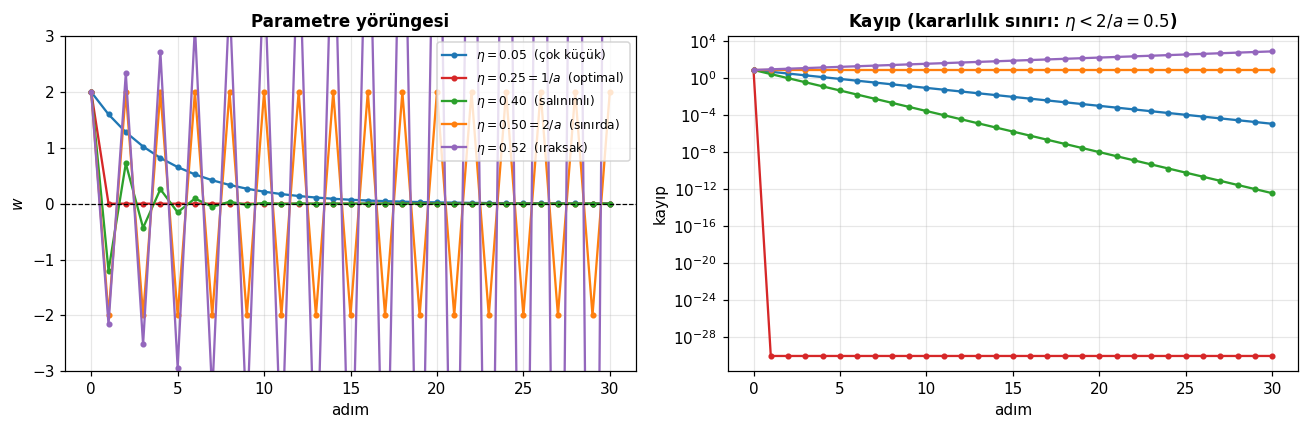

In [3]:
a = 4.0
w0 = 2.0
n_steps = 30

def gd_1d(eta, steps=n_steps):
    w, hist = w0, [w0]
    for _ in range(steps):
        w = w - eta * (a * w)
        hist.append(w)
    return np.array(hist)

etalar = {
    r"$\eta = 0.05$  (çok küçük)": 0.05,
    r"$\eta = 0.25 = 1/a$  (optimal)": 1.0 / a,
    r"$\eta = 0.40$  (salınımlı)": 0.40,
    r"$\eta = 0.50 = 2/a$  (sınırda)": 2.0 / a,
    r"$\eta = 0.52$  (ıraksak)": 0.52,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, (lab, eta) in enumerate(etalar.items()):
    h = gd_1d(eta)
    axes[0].plot(h, "-o", ms=3, label=lab, color=optim.viz.PALETTE[i])
    axes[1].plot(0.5 * a * h ** 2 + 1e-30, "-o", ms=3, color=optim.viz.PALETTE[i])

axes[0].axhline(0, color="k", lw=0.8, ls="--")
axes[0].set_ylim(-3, 3); axes[0].set_xlabel("adım"); axes[0].set_ylabel("$w$")
axes[0].set_title("Parametre yörüngesi"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_yscale("log"); axes[1].set_xlabel("adım"); axes[1].set_ylabel("kayıp")
axes[1].set_title(f"Kayıp (kararlılık sınırı: $\\eta < 2/a = {2/a}$)"); axes[1].grid(alpha=0.3)
plt.show()

Sol grafikte $\eta = 0.52$ eğrisinin ekrandan taştığına dikkat edin —
her adımda genlik büyüyor. Sağdaki log ölçekli grafikte ise ıraksama
doğrusal olarak yukarı çıkan bir doğru olarak görünüyor.

**Pratik çıkarım:** Eğitim sırasında kayıp `NaN` oluyorsa ilk şüpheli
daima öğrenme oranıdır.

---
## 4. Koşul sayısı: zikzak probleminin kaynağı

Çok boyutta $L(w) = \tfrac12 w^\top A w$ için Hessian $A$'dır. Özdeğerleri
$\lambda_{\max} \ge \dots \ge \lambda_{\min} > 0$ olsun. **Koşul sayısı:**

$$\kappa = \frac{\lambda_{\max}}{\lambda_{\min}}$$

Kararlılık $\eta < 2/\lambda_{\max}$ ister; ama en yavaş yön
$\lambda_{\min}$ yönüdür ve o yöndeki yakınsama hızı $(1-\eta\lambda_{\min})$'dir.
$\eta$'yi $\lambda_{\max}$'a göre seçmek zorunda olduğumuz için
$\lambda_{\min}$ yönü **$\kappa$ kat yavaş** ilerler.

Optimal $\eta$ ile gradyan inişinin yakınsama oranı:

$$
\frac{L(w_t) - L^\star}{L(w_0) - L^\star} \le \left(\frac{\kappa-1}{\kappa+1}\right)^{2t}
$$

$\kappa = 100$ için bu oran $0.9802^{2t}$ — 100 adımda ancak ~55 kat
iyileşme. $\kappa=1$ olsaydı tek adımda biterdi.

**Derin ağlarda $\kappa$ tipik olarak $10^3$–$10^6$ mertebesindedir.**
Bu dersteki her algoritma, bir bakıma, $\kappa$'nın etkisini azaltma
çabasıdır:

- **Momentum**: $\kappa$ yerine $\sqrt{\kappa}$ bağımlılığı
- **Adaptif yöntemler**: her koordinatı ayrı ölçekleyerek $\kappa$'yı düşürme
- **L-BFGS**: Hessian'ı yaklaşık tersine çevirerek $\kappa \to 1$

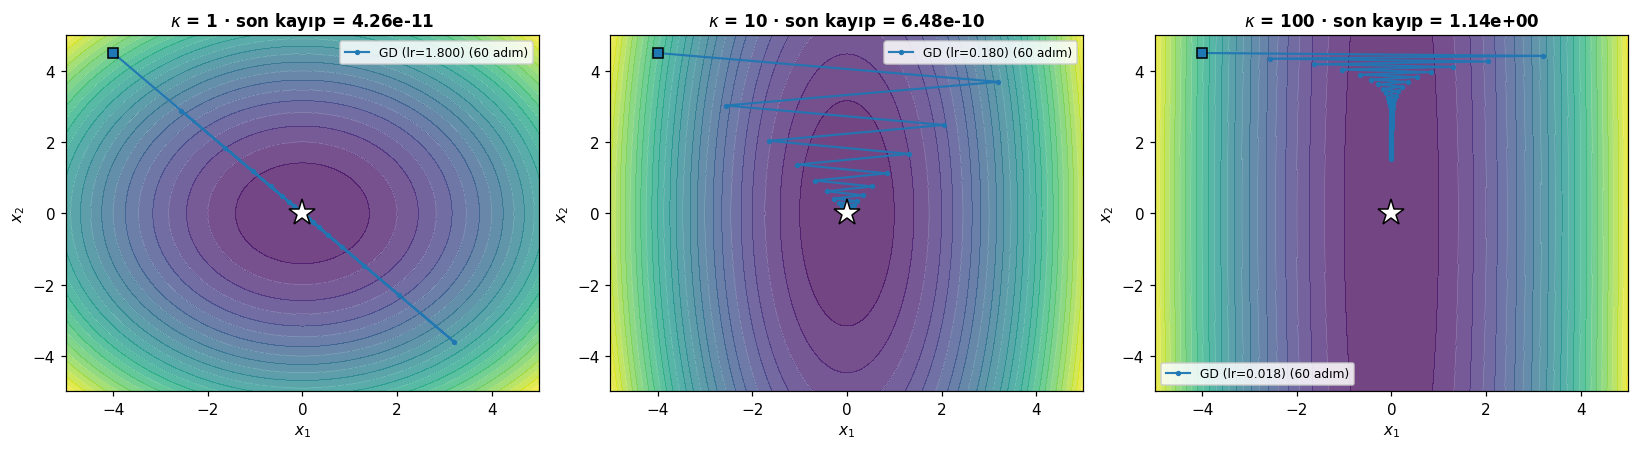

In [4]:
from optim import SGD, optimize_2d
from optim.viz import plot_paths

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, kappa in zip(axes, [1.0, 10.0, 100.0]):
    fn = Quadratic(a=kappa, b=1.0)
    lr = 0.9 * (2.0 / kappa)          # kararlılık sınırının %90'ı
    path, losses = optimize_2d(SGD, fn, [-4.0, 4.5], n_steps=60, lr=lr)
    plot_paths(fn, [path], [f"GD (lr={lr:.3f})"], ax=ax)
    ax.set_title(f"$\\kappa$ = {kappa:.0f} · son kayıp = {losses[-1]:.2e}")
plt.show()

$\kappa=1$'de yörünge doğrudan merkeze iner. $\kappa$ büyüdükçe klasik
**zikzak** deseni ortaya çıkar: dik yönde ileri-geri sıçrarken, vadinin
uzun ekseni boyunca sürünerek ilerler.

---
## 5. Konveks olmayan dünya

Yukarıdaki analiz konveks kuadratikler içindi. Sinir ağlarının kayıp
yüzeyi konveks **değildir**. Üç tür kritik nokta vardır ($\nabla L = 0$):

| Tür | Hessian özdeğerleri | Yüksek boyutta sıklığı |
|---|---|---|
| Yerel minimum | hepsi > 0 | Nadir |
| Yerel maksimum | hepsi < 0 | Çok nadir |
| **Eyer noktası** | karışık işaretli | **Ezici çoğunluk** |

$d$ boyutta rastgele bir kritik noktanın minimum olma olasılığı kabaca
$2^{-d}$'dir — $d=10^6$ için pratikte sıfır. Dolayısıyla derin öğrenmede
asıl düşman yerel minimumlar değil, **eyer noktaları ve platolardır**.

Eyer noktasında gradyan sıfıra yakındır ama biz minimumda değilizdir.
Saf gradyan inişi buralarda çok uzun süre takılır; momentum ve adaptif
yöntemler çıkışı hızlandırır.

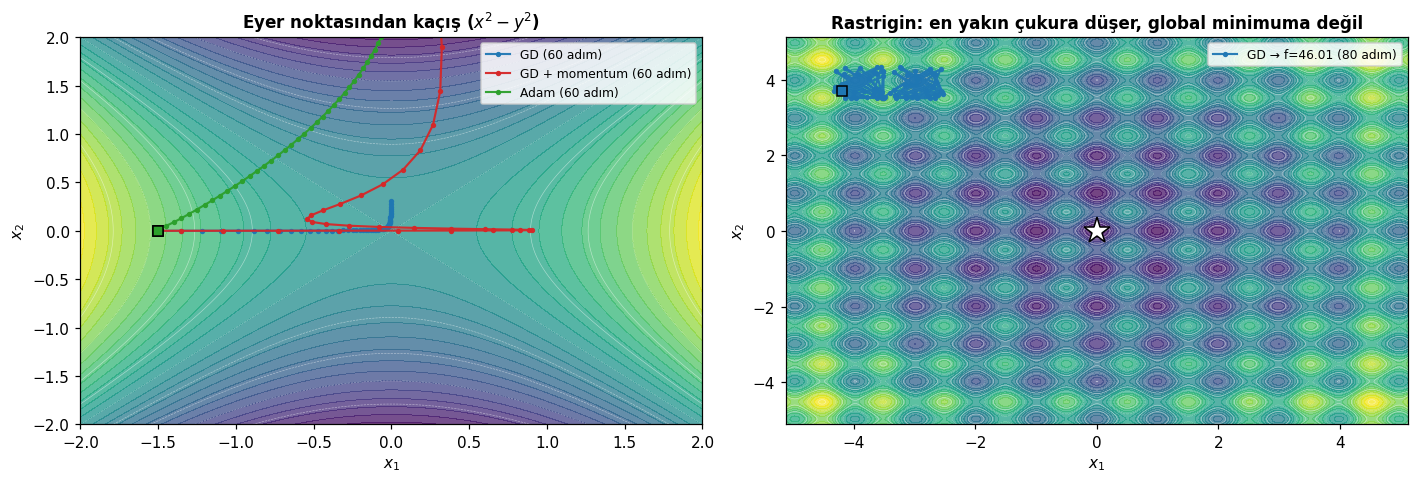

In [5]:
from optim.functions import Saddle, Rastrigin
from optim import Adam

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Eyer noktası: GD vs Momentum vs Adam
saddle = Saddle()
x0 = [-1.5, 1e-3]                     # eyerin tam üstüne yakın başla
runs = [(SGD, dict(lr=0.05), "GD"),
        (SGD, dict(lr=0.05, momentum=0.9), "GD + momentum"),
        (Adam, dict(lr=0.05), "Adam")]
paths, labels = [], []
for cls, kw, name in runs:
    p, _ = optimize_2d(cls, saddle, x0, n_steps=60, **kw)
    paths.append(p); labels.append(name)
plot_paths(saddle, paths, labels, ax=axes[0])
axes[0].set_title("Eyer noktasından kaçış ($x^2 - y^2$)")

# (b) Çok sayıda yerel minimum
rast = Rastrigin()
p, l = optimize_2d(SGD, rast, rast.default_start, n_steps=80, lr=0.01)
plot_paths(rast, [p], [f"GD → f={l[-1]:.2f}"], ax=axes[1])
axes[1].set_title("Rastrigin: en yakın çukura düşer, global minimuma değil")
plt.show()

Soldaki grafikte üç yöntem de eyerden kaçıyor ama hızları çok farklı:
Adam ve momentum, $y$ yönündeki küçük gradyanı hızla büyütürken saf GD
başlangıçta neredeyse hiç hareket etmiyor.

Sağdaki Rastrigin örneği ise ayık bir hatırlatma: **hiçbir gradyan
tabanlı yöntem global minimumu garanti etmez.** Derin öğrenmede bununla
yaşıyoruz — pratikte "yeterince iyi" bir yerel minimum bulmak yetiyor.

---
## 6. Batch, Mini-batch ve Stokastik gradyan

Gerçek gradyan tüm veri üzerinden hesaplanır:

$$\nabla L(w) = \frac{1}{n}\sum_{i=1}^{n} \nabla \ell_i(w)$$

$n$ milyonlarca ise bu tek bir adım için bile pahalıdır. Çözüm: rastgele
seçilmiş $B$ örneklik bir alt kümeyle **yansız** tahmin yapmak:

$$
\hat{g} = \frac{1}{B}\sum_{i \in \mathcal{B}} \nabla \ell_i(w),
\qquad
\mathbb{E}[\hat{g}] = \nabla L(w),
\qquad
\mathrm{Var}[\hat{g}] \propto \frac{1}{B}
$$

Kritik sonuç: **gradyan gürültüsünün standart sapması $1/\sqrt{B}$ ile
azalır.** Batch'i 4 katına çıkarmak gürültüyü yalnızca yarıya indirir
ama hesabı 4 katına çıkarır — azalan verim yasası.

Gürültü her zaman kötü değildir:
- **Kötü yanı:** minimum civarında tam oturmayı engeller (gürültü tabanı)
- **İyi yanı:** keskin minimumlardan kaçırır, düzenlileştirici etki yapar

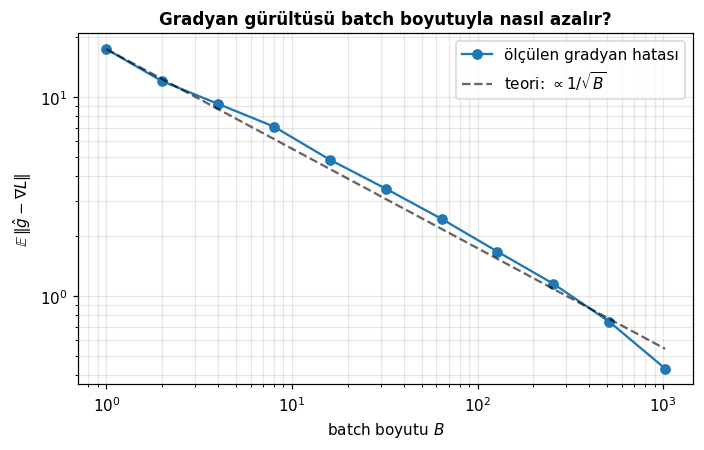

Ölçülen eğim (log-log) : -0.5169015718316596
Teorik eğim            : -0.5


In [6]:
from optim.models import LinearRegression
from optim.data import make_regression_data

X, y, w_true = make_regression_data(n=2000, d=20, noise=0.5, seed=0)
model = LinearRegression(20)
tam_grad = model.loss_and_grads(X, y)[1][0]

rng = np.random.default_rng(1)
batch_sizes = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
sapmalar = []
for B in batch_sizes:
    hatalar = []
    for _ in range(200):
        idx = rng.choice(len(X), size=B, replace=False)
        g = model.loss_and_grads(X[idx], y[idx])[1][0]
        hatalar.append(np.linalg.norm(g - tam_grad))
    sapmalar.append(np.mean(hatalar))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(batch_sizes, sapmalar, "-o", color=optim.viz.PALETTE[0],
          label="ölçülen gradyan hatası")
ref = sapmalar[0] * (np.array(batch_sizes, dtype=float)) ** -0.5
ax.loglog(batch_sizes, ref, "--", color="k", alpha=0.6, label=r"teori: $\propto 1/\sqrt{B}$")
ax.set_xlabel("batch boyutu $B$"); ax.set_ylabel(r"$\mathbb{E}\,\|\hat{g} - \nabla L\|$")
ax.set_title("Gradyan gürültüsü batch boyutuyla nasıl azalır?")
ax.grid(alpha=0.3, which="both"); ax.legend()
plt.show()

print("Ölçülen eğim (log-log) :", np.polyfit(np.log(batch_sizes), np.log(sapmalar), 1)[0])
print("Teorik eğim            : -0.5")

Ölçülen eğim teorik $-0.5$ değerine çok yakın çıkıyor. Bu, batch boyutu
ve öğrenme oranı arasındaki ünlü **doğrusal ölçekleme kuralının**
(linear scaling rule) temelidir: batch $k$ katına çıkarsa öğrenme
oranını da yaklaşık $k$ katına çıkarabilirsiniz.

---
## 7. Gradyan doğrulama — pazarlık konusu değil

Elle yazılmış her gradyan hatalıdır, aksi kanıtlanana kadar. Kontrol
yöntemi **merkezi sonlu fark**:

$$
\frac{\partial L}{\partial w_i} \approx \frac{L(w + \epsilon e_i) - L(w - \epsilon e_i)}{2\epsilon}
\qquad \text{hata } O(\epsilon^2)
$$

İleri fark $O(\epsilon)$ hatalıdır; bu yüzden daima merkezi fark kullanın.

Bağıl hata ölçütü:

$$
\text{rel} = \frac{\|g_{\text{analitik}} - g_{\text{sayısal}}\|}{\|g_{\text{analitik}}\| + \|g_{\text{sayısal}}\|}
$$

| rel | Yorum |
|---|---|
| $< 10^{-7}$ | Mükemmel |
| $10^{-7} - 10^{-5}$ | Kabul edilebilir (çift hassasiyet) |
| $> 10^{-3}$ | **Kesinlikle hata var** |

> ReLU kullanıyorsanız $z=0$ civarında sonlu fark yanıltıcı olabilir
> (türev süreksiz). Kontrolü rastgele noktalarda birkaç kez tekrarlayın.

In [7]:
from optim.functions import check_grad, Rosenbrock, Beale
from optim.models import MLP

print("Test fonksiyonları:")
for F in [Quadratic(), Rosenbrock(), Beale(), Rastrigin()]:
    ok, rel = check_grad(F.value, F.grad, np.array([0.7, -0.35]), verbose=False)
    print(f"  {F.name:26s} rel = {rel:.2e}  {'GEÇTİ' if ok else 'KALDI'}")

# Şimdi MLP'nin elle yazılmış geri yayılımını kontrol edelim
rng = np.random.default_rng(0)
Xs = rng.normal(size=(16, 5))
ys = rng.integers(0, 3, size=16)
mlp = MLP([5, 8, 6, 3], activation="tanh", l2=0.01, seed=3)

shapes = [p.shape for p in mlp.params]
sizes = [p.size for p in mlp.params]

def set_params(v):
    off = 0
    for p, s, sh in zip(mlp.params, sizes, shapes):
        p[...] = v[off:off + s].reshape(sh)
        off += s

def f_of_v(v):
    set_params(v)
    return mlp.loss_and_grads(Xs, ys)[0]

def g_of_v(v):
    set_params(v)
    return np.concatenate([g.ravel() for g in mlp.loss_and_grads(Xs, ys)[1]])

v0 = np.concatenate([p.ravel().copy() for p in mlp.params])
ok, rel = check_grad(f_of_v, g_of_v, v0, eps=1e-6, tol=1e-5, verbose=False)
print(f"\nMLP geri yayılımı ({mlp.n_params()} parametre): rel = {rel:.2e}  "
      f"{'GEÇTİ' if ok else 'KALDI'}")

Test fonksiyonları:
  Kötü Koşullu Kuadratik     rel = 2.25e-11  GEÇTİ
  Rosenbrock                 rel = 1.34e-11  GEÇTİ
  Beale                      rel = 3.74e-11  GEÇTİ
  Rastrigin                  rel = 3.24e-11  GEÇTİ

MLP geri yayılımı (123 parametre): rel = 6.77e-10  GEÇTİ


---
## 8. Derste kullanacağımız ortak arayüz

Beş algoritmayı adil biçimde karşılaştırabilmek için hepsi aynı
sözleşmeyi paylaşır (PyTorch'un tasarımını taklit eder):

```python
optimizer = Optimizer(params, lr=...)   # params: list[np.ndarray]
optimizer.step(grads)                   # grads:  list[np.ndarray]
```

Parametreler **yerinde (in-place)** güncellenir; model ve optimizer aynı
diziyi paylaşır. Model tarafındaki sözleşme ise:

```python
loss, grads = model.loss_and_grads(X, y)
```

Bu iki sözleşme sayesinde eğitim döngüsü tüm optimizer'lar için aynıdır.

Eğitim: (426, 30), Test: (143, 30)
SGD       son kayıp=0.0656  test doğruluk=96.50%
SGD+Mom   son kayıp=0.0446  test doğruluk=96.50%
RMSProp   son kayıp=0.0497  test doğruluk=96.50%
Adam      son kayıp=0.0561  test doğruluk=95.80%
AdamW     son kayıp=0.0566  test doğruluk=95.80%


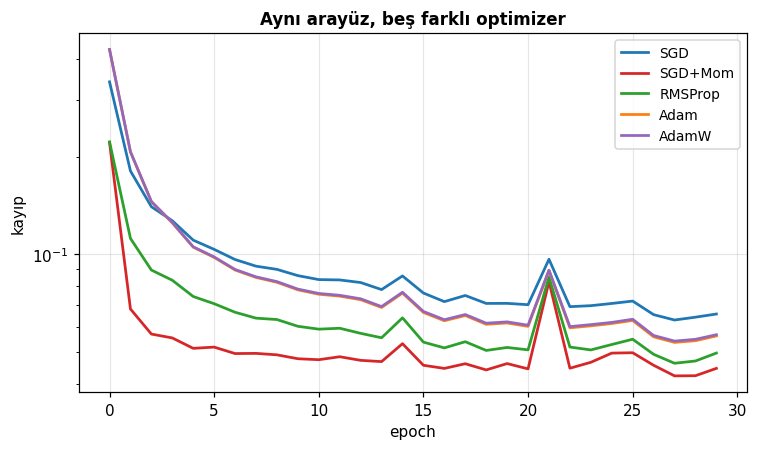

In [8]:
from optim import SGD, Adam, RMSProp, AdamW, train
from optim.models import LogisticRegression
from optim.data import load_breast_cancer_data

X_tr, X_te, y_tr, y_te = load_breast_cancer_data(seed=0)
print(f"Eğitim: {X_tr.shape}, Test: {X_te.shape}")

sonuclar = {}
for name, cls, kw in [("SGD",        SGD,     dict(lr=0.1)),
                      ("SGD+Mom",    SGD,     dict(lr=0.1, momentum=0.9)),
                      ("RMSProp",    RMSProp, dict(lr=0.01)),
                      ("Adam",       Adam,    dict(lr=0.01)),
                      ("AdamW",      AdamW,   dict(lr=0.01, weight_decay=0.01))]:
    model = LogisticRegression(X_tr.shape[1], seed=0)
    opt = cls(model.params, **kw)
    hist = train(model, X_tr, y_tr, opt, n_epochs=30, batch_size=32,
                 X_val=X_te, y_val=y_te, seed=0)
    sonuclar[name] = hist
    print(f"{name:9s} son kayıp={hist['epoch_loss'][-1]:.4f}  "
          f"test doğruluk={hist['val_acc'][-1]*100:.2f}%")

fig, ax = plt.subplots(figsize=(7, 4.2))
optim.viz.plot_losses([h["epoch_loss"] for h in sonuclar.values()],
                      list(sonuclar), ax=ax, xlabel="epoch",
                      title="Aynı arayüz, beş farklı optimizer")
plt.show()

Beş optimizer, tek satır değiştirilerek aynı model üzerinde çalıştı.
Ders boyunca bu kurulumu kullanacağız.

---
## 9. Alıştırmalar

**A1 (kolay).** `gd_1d` fonksiyonunu $a = 4$ için $\eta = 2/a$ tam
değerinde çalıştırın. Yörünge neden yakınsamıyor ama ıraksamıyor da?
Analitik olarak açıklayın.

**A2 (kolay).** `Quadratic(a=50, b=1)` için kararlılık sınırını hesaplayın.
Sınırın hemen altında ve hemen üstünde birer koşum yapıp kayıp eğrilerini
çizin.

**A3 (orta).** Bölüm 6'daki gürültü deneyini `replace=True` ile
(yerine koyarak örnekleme) tekrarlayın. Eğim değişiyor mu? Neden?

**A4 (orta).** `TestFunction` sınıfından türeterek **Himmelblau**
fonksiyonunu ekleyin:
$f(x,y) = (x^2+y-11)^2 + (x+y^2-7)^2$.
Analitik gradyanını yazın ve `check_grad` ile doğrulayın. Dört farklı
başlangıç noktasından GD çalıştırıp dört farklı minimuma gittiğini gösterin.

**A5 (zor).** $L(w) = \tfrac12 w^\top A w$ için, $A$'nın özayrışımını
kullanarak gradyan inişinin her özyön boyunca bağımsız evrildiğini
gösterin: $\tilde{w}^{(i)}_t = (1-\eta\lambda_i)^t \tilde{w}^{(i)}_0$.
Bunu $2\times2$ bir örnekte sayısal olarak doğrulayın.

**A6 (zor).** Sonlu fark adımı $\epsilon$'u $10^{-1}$'den $10^{-12}$'ye
değiştirerek `check_grad`'in bağıl hatasını çizin. Hata neden önce
azalıp sonra artıyor? (İpucu: kesme hatası vs yuvarlama hatası.)

Çözümler: `alistirmalar/cozumler/cozumler_00.py`

---
## Sonraki adım
**`01_sgd_momentum.ipynb`** — SGD, momentum ve Nesterov'u sıfırdan yazıyoruz.